In [1]:
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(dplyr)
  library(NMF)
  library(pdacR)
  library(Seurat)
  library(Matrix)
  library(singscore)
  library(tidyverse)
})


Warning message:
“replacing previous import ‘Seurat::Assays’ by ‘SummarizedExperiment::Assays’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘ggpubr::mutate’ by ‘plyr::mutate’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘Biobase::exprs’ by ‘rlang::exprs’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘readr::col_factor’ by ‘scales::col_factor’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘shiny::runExample’ by ‘shinyjs::runExample’ when loading ‘pdacR’”
Warning message:
“replacing previous import ‘limma::show’ by ‘shinyjs::show’ when loading ‘pdacR’”
Warning message:
“‘timedatectl’ indicates the non-existent timezone name ‘n/a’”
Warning message:
“Your system is mis-configured: ‘/etc/localtime’ is not a symlink”
Warning message:
“‘/etc/localtime’ is not identical to any known timezone file”


In [2]:
#pdacR::gene_lists

## Loading data

In [3]:
met_high_df <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-high-genes-human.csv")
met_low_df  <- read.csv("/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/met-low-genes-human.csv")
met_high_genes <- na.omit(met_high_df$SYMBOL)
met_low_genes  <- na.omit(met_low_df$SYMBOL)

file_path <- system.file("data", "TCGA_PAAD.rds", package = "pdacR")
TCGA_PAAD <- readRDS(file_path)

In [4]:
#TCGA_PAAD

## Preparing MetScore Label

In [5]:
# PREPARE THE EXPRESSION MATRIX
expression_matrix <- as.matrix(TCGA_PAAD$ex)

rownames(expression_matrix) <- TCGA_PAAD$featInfo$SYMBOL

tcga_paad_ranked <- rankGenes(expression_matrix)

In [6]:
# Calculate the MetScore using simpleScore
met_scores <- simpleScore(tcga_paad_ranked, upSet = met_high_genes, downSet = met_low_genes)

Warning message in checkGenes(upSet, rownames(rankData)):
“14 genes missing: SPMIP3, CAVIN2, NABP1, CFAP69, CRACR2A, TENT5B, ACKR3, TMEM238L, JADE3, SEPTIN8, TMPRSS11E, SOWAHB, NHSL3, ARHGAP40”
Warning message in checkGenes(downSet, rownames(rankData)):
“14 genes missing: ENTREP1, NREP, PIEZO2, CCN3, CPED1, ADGRF5, AOPEP, GPR15LG, MALRD1, CLDN34, DENND11, ARHGAP44, KNOP1, FAM222B”


In [7]:
#met_scores

In [8]:
TCGA_PAAD$sampInfo$MetScore <- met_scores$TotalScore

## Preparing TCGA

In [9]:
## Preparation of TCGA data
#RSEM counts can be rounded to the nearest integer
## RSEM assigns reads with multiple mappings -- they are counts, but a fractional amount can be assigned to a gene.
TCGA_PAAD$ex <- round(TCGA_PAAD$ex)


#remove expression of unhelpful "?" genes
#this gives the index of rows that are "?"
feat_q <- which(TCGA_PAAD$featInfo == "?")
## TCGA_PAAD is organized so that the rows of ex are in the same order as featInfo (feature info)
## and the columns of ex are in the same order as sampInfo (sample info)
# To maintain this order, removals need to be done to both 
TCGA_PAAD$ex <- TCGA_PAAD$ex[-feat_q,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-feat_q,]


#------------------

## "whitelist" filter determined by original TCGA paper
# remove the samples that are not part of the whitelist
wl_filter <- TCGA_PAAD$sampInfo$Filter_by == "whitelist"
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[wl_filter,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,wl_filter]

#------------------


# remove TCGA-US-A776 (outlier, precursor tumor)
# This sample is part of the whitelist, but is not PDAC
USA776 <- which(TCGA_PAAD$sampInfo$Tumor.Sample.ID == "TCGA-US-A776-01A")
TCGA_PAAD$sampInfo <- TCGA_PAAD$sampInfo[-USA776,]
TCGA_PAAD$ex <- TCGA_PAAD$ex[,-USA776]

#------------------

## Some genes have 0 expression across all samples and can be removed
remove0 <- which(rowSums(TCGA_PAAD$ex) == 0)
TCGA_PAAD$ex <- TCGA_PAAD$ex[-remove0,]
TCGA_PAAD$featInfo <- TCGA_PAAD$featInfo[-remove0,]


## Check that they still have the same number of genes
dim(TCGA_PAAD$ex)

[1] 19840   149

In [10]:
dim(TCGA_PAAD$featInfo)

[1] 19840     2

## Preparing genelist (substituted with Jesse's met-high and met-low genelist)

### Checking Overlaps

In [11]:
group_lists <- list(
  "Endocrine" = gene_lists$Moffitt.F12_Endocrine.top250,
  "Exocrine" = gene_lists$Moffitt.F3_Exocrine.top250,
  "Activated Stroma" = gene_lists$Moffitt.F5_ActivatedStroma.top250,
  "Normal Stroma" = gene_lists$Moffitt.F13_NormalStroma.top250,
  "Immune" = gene_lists$Moffitt.F7_Immune.top250,
  "MetHigh" = met_high_genes,  
  "MetLow" = met_low_genes
)


all_genes <- unlist(group_lists)

gene_counts <- table(all_genes)

overlapping_genes <- names(gene_counts[gene_counts > 1])


overlap_locations <- sapply(overlapping_genes, function(gene) {

  found_in_groups <- names(group_lists)[sapply(group_lists, function(g) gene %in% g)]
  
  paste(found_in_groups, collapse = " + ")
})


overlap_details_df <- data.frame(
  Gene = overlapping_genes,
  Belongs_To_Groups = overlap_locations,
  row.names = NULL
)


#print(overlap_details_df)

In [12]:
overlap_details_df$Belongs_To_Groups <- as.factor(overlap_details_df$Belongs_To_Groups)


overlap_frequencies <- summary(overlap_details_df$Belongs_To_Groups)
print(overlap_frequencies)

Activated Stroma + MetHigh  Activated Stroma + MetLow 
                         1                          8 
       Endocrine + MetHigh         Endocrine + MetLow 
                         3                          1 
        Exocrine + MetHigh          Exocrine + MetLow 
                         1                          5 
          Immune + MetHigh    Normal Stroma + MetHigh 
                         1                          2 
    Normal Stroma + MetLow 
                         4 


In [13]:
met_high_genes_clean <- setdiff(met_high_genes, overlapping_genes)
met_low_genes_clean <- setdiff(met_low_genes, overlapping_genes)


print(paste("[MetHigh] Original Count:", length(met_high_genes), 
            "-> Cleaned Count:", length(met_high_genes_clean)))

print(paste("[MetLow] Original Count:", length(met_low_genes), 
            "-> Cleaned Count:", length(met_low_genes_clean)))

[1] "[MetHigh] Original Count: 202 -> Cleaned Count: 194"
[1] "[MetLow] Original Count: 174 -> Cleaned Count: 156"


### create the full gene list for the nmf

In [14]:
sub_genelist <- data.frame(SYMBOL=gene_lists$Moffitt.F12_Endocrine.top250, class="Endocrine") %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F3_Exocrine.top250, class="Exocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F5_ActivatedStroma.top250, class="Activated Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F13_NormalStroma.top250, class="Normal Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F7_Immune.top250, class="Immune")) %>%
  rbind(data.frame(SYMBOL=met_high_genes_clean, class="MetHigh")) %>%    
  rbind(data.frame(SYMBOL=met_low_genes_clean, class="MetLow"))       

In [15]:
rownames(sub_genelist) <- sub_genelist$SYMBOL

ex_sub <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% sub_genelist$SYMBOL, ]
featInfo_sub <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% sub_genelist$SYMBOL, ]


dim(ex_sub)
dim(featInfo_sub)

[1] 1477  149

[1] 1477    2

## Setting up NMF

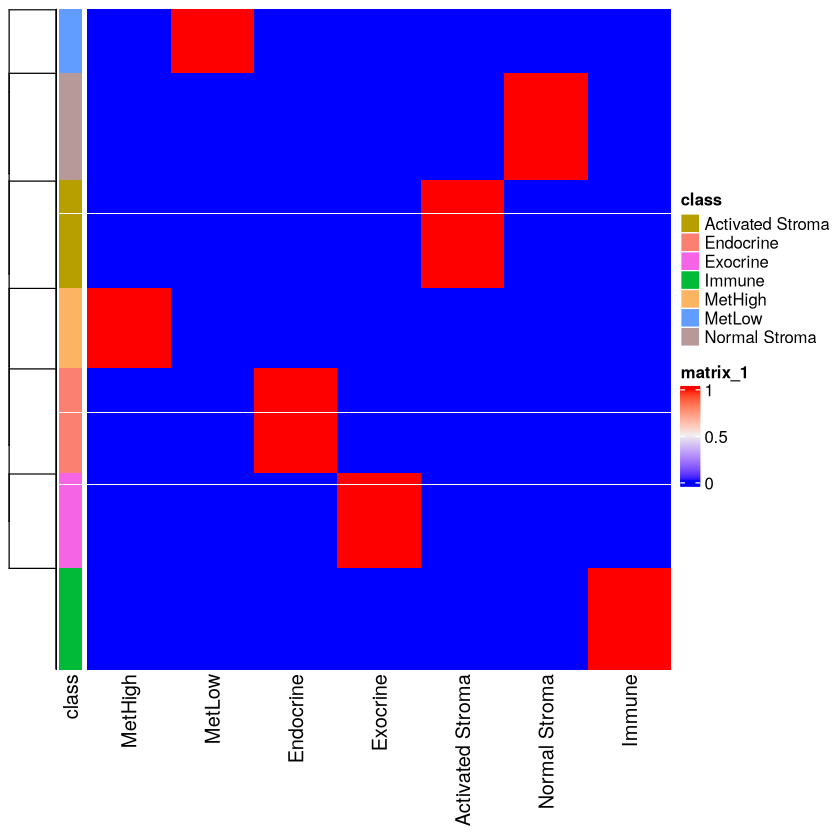

In [16]:
k <- 7
RNA_val <- 1
default_RNA <- 0.01


W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_sub), ncol=k)


W.seed.rna[which(featInfo_sub$SYMBOL %in% met_high_genes_clean), 1] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% met_low_genes_clean), 2] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F12_Endocrine.top250), 3] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F3_Exocrine.top250), 4] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F5_ActivatedStroma.top250), 5] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F13_NormalStroma.top250), 6] <- RNA_val
W.seed.rna[which(featInfo_sub$SYMBOL %in% gene_lists$Moffitt.F7_Immune.top250), 7] <- RNA_val



colnames(W.seed.rna) <- c("MetHigh", "MetLow", "Endocrine", "Exocrine",
                          "Activated Stroma", "Normal Stroma", "Immune"
                          )


Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = sub_genelist[featInfo_sub$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("MetHigh" = "#fdb462", "MetLow" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38")
          )
        )
)



In [17]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_sub))

H.seed.rna <- nmf_update.euclidean.h(ex_sub, W.seed.rna, H.seed.rna)


In [18]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_sub, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

## Solution to W matrix for RNA

In [19]:
RNA_W <- RNA_solved@fit@W

ht_sub_w <- Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          
          df = sub_genelist[featInfo_sub$SYMBOL, "class", drop = FALSE],
          col = list(
            
            class = c("MetHigh" = "#fdb462", "MetLow" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38")
          )
        )
)

png(filename = "/scratch/hhuan40/Spatial-MetScore-JS/figures/nmf/SUBheatmap_RNA_W.png", width = 10, height = 8, units = "in", res = 300)

# pdf(file = "figure/nmf/heatmap_RNA_H.pdf", width = 10, height = 8)


draw(ht_sub_w)
dev.off()

agg_record_c5405c5f8a87 
                      2

## Solution to H matrix for RNA

In [20]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID


rownames(RNA_H) <- c("MetHigh", "MetLow", "Endocrine", "Exocrine",
                     "Activated Stroma", "Normal Stroma", "Immune"
                     )

ht_sub_h <- Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("MetScore", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            MetScore = colorRamp2(c(0, 0.15), c("white", "red")),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)



png(filename = "/scratch/hhuan40/Spatial-MetScore-JS/figures/nmf/SUBheatmap_RNA_H.png", width = 10, height = 8, units = "in", res = 300)



draw(ht_sub_h)
dev.off()

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



agg_record_c54038435e9a 
                      2

In [21]:
ht_sub_h_scaled <- Heatmap(scale(RNA_H), cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("MetScore", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            MetScore = colorRamp2(c(0, 0.15), c("white", "red")),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

png(filename = "/scratch/hhuan40/Spatial-MetScore-JS/figures/nmf/SUBheatmap_RNA_H_scaled.png", width = 10, height = 8, units = "in", res = 300)



draw(ht_sub_h_scaled)
dev.off()

agg_record_c5403ed44067 
                      2

In [22]:
#TCGA_PAAD$sampInfo$MetScore

# With other classification

### Checking duplicate in the Met genes and delete them from the list

In [23]:
group_lists <- list(
  "Basal-like" = gene_lists$Moffitt.F6_BasalLike.top250,
  "Classical" = gene_lists$Moffitt.F8_Classical.top250,
  "Endocrine" = gene_lists$Moffitt.F12_Endocrine.top250,
  "Exocrine" = gene_lists$Moffitt.F3_Exocrine.top250,
  "Activated Stroma" = gene_lists$Moffitt.F5_ActivatedStroma.top250,
  "Normal Stroma" = gene_lists$Moffitt.F13_NormalStroma.top250,
  "Immune" = gene_lists$Moffitt.F7_Immune.top250,
  "MetHigh" = met_high_genes,  
  "MetLow" = met_low_genes
)


all_genes <- unlist(group_lists)

gene_counts <- table(all_genes)

overlapping_genes <- names(gene_counts[gene_counts > 1])


overlap_locations <- sapply(overlapping_genes, function(gene) {

  found_in_groups <- names(group_lists)[sapply(group_lists, function(g) gene %in% g)]
  
  paste(found_in_groups, collapse = " + ")
})


overlap_details_df <- data.frame(
  Gene = overlapping_genes,
  Belongs_To_Groups = overlap_locations,
  row.names = NULL
)


#print(overlap_details_df)

In [24]:
overlap_details_df$Belongs_To_Groups <- as.factor(overlap_details_df$Belongs_To_Groups)


overlap_frequencies <- summary(overlap_details_df$Belongs_To_Groups)
print(overlap_frequencies)

Activated Stroma + MetHigh  Activated Stroma + MetLow 
                         1                          8 
      Basal-like + MetHigh        Classical + MetHigh 
                        13                          3 
        Classical + MetLow        Endocrine + MetHigh 
                         4                          3 
        Endocrine + MetLow         Exocrine + MetHigh 
                         1                          1 
         Exocrine + MetLow           Immune + MetHigh 
                         5                          1 
   Normal Stroma + MetHigh     Normal Stroma + MetLow 
                         2                          4 


In [25]:
met_high_genes_clean <- setdiff(met_high_genes, overlapping_genes)
met_low_genes_clean <- setdiff(met_low_genes, overlapping_genes)


print(paste("[MetHigh] Original Count:", length(met_high_genes), 
            "-> Cleaned Count:", length(met_high_genes_clean)))

print(paste("[MetLow] Original Count:", length(met_low_genes), 
            "-> Cleaned Count:", length(met_low_genes_clean)))

[1] "[MetHigh] Original Count: 202 -> Cleaned Count: 178"
[1] "[MetLow] Original Count: 174 -> Cleaned Count: 152"


In [26]:
combined_genelist <- data.frame(SYMBOL=gene_lists$Moffitt.F6_BasalLike.top250, class="Basal-like") %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F8_Classical.top250, class="Classical")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F12_Endocrine.top250, class="Endocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F3_Exocrine.top250, class="Exocrine")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F5_ActivatedStroma.top250, class="Activated Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F13_NormalStroma.top250, class="Normal Stroma")) %>%
  rbind(data.frame(SYMBOL=gene_lists$Moffitt.F7_Immune.top250, class="Immune")) %>%
  rbind(data.frame(SYMBOL=met_high_genes_clean, class="MetHigh")) %>%    
  rbind(data.frame(SYMBOL=met_low_genes_clean, class="MetLow"))          

In [27]:
rownames(combined_genelist) <- combined_genelist$SYMBOL

ex_combined <- TCGA_PAAD$ex[TCGA_PAAD$featInfo$SYMBOL %in% combined_genelist$SYMBOL, ]
featInfo_combined <- TCGA_PAAD$featInfo[TCGA_PAAD$featInfo$SYMBOL %in% combined_genelist$SYMBOL, ]


dim(ex_combined)
dim(featInfo_combined)

[1] 1925  149

[1] 1925    2

In [28]:
temp_df <- combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE]

# 查看 df 中到底有哪些分类，以及是否有 NA
table(temp_df$class, useNA = "always")


Activated Stroma       Basal-like        Classical        Endocrine 
             240              237              230              235 
        Exocrine           Immune          MetHigh           MetLow 
             211              228              165              138 
   Normal Stroma             <NA> 
             241                0 

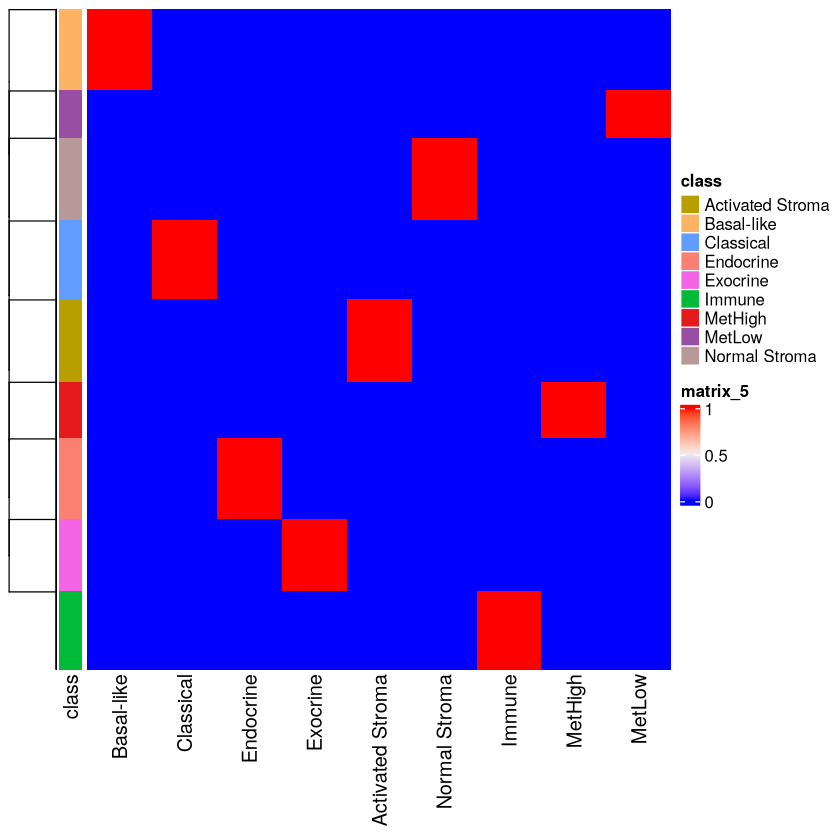

In [29]:
k <- 9
RNA_val <- 1
default_RNA <- 0.01


W.seed.rna <- matrix(default_RNA, nrow=nrow(ex_combined), ncol=k)


W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F6_BasalLike.top250), 1] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F8_Classical.top250), 2] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F12_Endocrine.top250), 3] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F3_Exocrine.top250), 4] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F5_ActivatedStroma.top250), 5] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F13_NormalStroma.top250), 6] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% gene_lists$Moffitt.F7_Immune.top250), 7] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% met_high_genes_clean), 8] <- RNA_val
W.seed.rna[which(featInfo_combined$SYMBOL %in% met_low_genes_clean), 9] <- RNA_val


colnames(W.seed.rna) <- c("Basal-like", "Classical", "Endocrine", "Exocrine",
                          "Activated Stroma", "Normal Stroma", "Immune",
                          "MetHigh", "MetLow")


Heatmap(W.seed.rna, cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          df = combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE],
          col = list(
            class = c("Basal-like" = "#fdb462", "Classical" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38", "MetHigh" = "#E41A1C", "MetLow" = "#984EA3")
          )
        )
)


In [30]:
H.seed.rna <- matrix(0.05, nrow=k, ncol=ncol(ex_combined))

H.seed.rna <- nmf_update.euclidean.h(ex_combined, W.seed.rna, H.seed.rna)

In [31]:
RNA_seed <- NMF::nmfModel(W = W.seed.rna, H = H.seed.rna)

RNA_solved <- NMF::nmf(ex_combined, seed=RNA_seed, .opt=list(parallel=TRUE, verbose=FALSE))

In [32]:
RNA_W <- RNA_solved@fit@W

ht_combined_w <- Heatmap(t(scale(t(RNA_W))), cluster_columns = FALSE, cluster_rows = TRUE,
        left_annotation = rowAnnotation(
          
          df = combined_genelist[featInfo_combined$SYMBOL, "class", drop = FALSE],
          col = list(
            
            class = c("Basal-like" = "#fdb462", "Classical" = "#619cff", 
                      "Endocrine" = "#fb8072", "Exocrine" = "#f564e4", 
                      "Activated Stroma" = "#b79f00", "Normal Stroma" = "#b79999", 
                      "Immune" = "#00ba38", "MetHigh" = "#E41A1C", "MetLow" = "#984EA3")
          )
        )
)

png(filename = "/scratch/hhuan40/Spatial-MetScore-JS/figures/nmf/COMheatmap_RNA_W.png", width = 10, height = 8, units = "in", res = 300)



draw(ht_combined_w)
dev.off()

agg_record_c54071241fe3 
                      2

In [33]:
RNA_H <- RNA_solved@fit@H

colnames(RNA_H) <- TCGA_PAAD$sampInfo$Tumor.Sample.ID


rownames(RNA_H) <- c("Basal-like", "Classical", "Endocrine", "Exocrine",
                     "Activated Stroma", "Normal Stroma", "Immune",
                     "MetHigh", "MetLow")

ht_combined_h <- Heatmap(RNA_H, cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

png(filename = "/scratch/hhuan40/Spatial-MetScore-JS/figures/nmf/COMheatmap_RNA_H.png", width = 10, height = 8, units = "in", res = 300)



draw(ht_combined_h)
dev.off()

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



agg_record_c54037d26597 
                      2

In [34]:
ht_combined_h_scaled <- Heatmap(scale(RNA_H), cluster_columns = TRUE, cluster_rows = FALSE,
        
        top_annotation = HeatmapAnnotation(
          df = subset(TCGA_PAAD$sampInfo, select = c("Moffitt.Clusters", "ABSOLUTE.Purity", "Gender")),
          col = list(
            ABSOLUTE.Purity = colorRamp2(c(0, 0.7), c("white", "forestgreen")),
            Moffitt.Clusters = c("Basal-like" = "#fdb462", "Classical" = "#619cff"),
            Gender = c("male" = "#440154", "female" = "#fde725")
          )
        )
)

png(filename = "/scratch/hhuan40/Spatial-MetScore-JS/figures/nmf/COMheatmap_RNA_H_scaled.png", width = 10, height = 8, units = "in", res = 300)



draw(ht_combined_h_scaled)
dev.off()

agg_record_c5404934bfed 
                      2

# THE BIG NMF (ST data)

## Get MetScore for ST data

In [ ]:
# Loading the data
data_dir <- "/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/processed"


info_df <- read.csv(file.path(data_dir, "Visium_AllSpots_InfoTable_noMS.csv"), stringsAsFactors = FALSE)


expr_df <- read.csv(file.path(data_dir, "Visium_Expression_Matrix_for_NMF.csv"), row.names = 1, check.names = FALSE)

In [ ]:
expr_df

In [ ]:
expression_matrix <- as.matrix(expr_df)
visium_ranked <- rankGenes(expression_matrix)

In [ ]:
met_scores <- simpleScore(visium_ranked, upSet = met_high_genes, downSet = met_low_genes)

# 写入 Info 表 (对应你代码里的 TCGA_PAAD$sampInfo$MetScore <- met_scores$TotalScore)
# 注意：我们这里通过 Spot_ID 确保绝对对齐
info_df$MET_Score <- met_scores$TotalScore[match(info_df$Spot_ID, rownames(met_scores))]

In [ ]:
final_columns <- c(
  "Patient_Source", 
  "Sample_Name", 
  "Organ", 
  "Reads", 
  "MET_Score", 
  "ESTIMATE_TumorPurity", 
  "ESTIMATE_ImmuneScore", 
  "ESTIMATE_StromaScore"
)

# 将 Spot_ID 设为行名，并提取这 8 列
rownames(info_df) <- info_df$Spot_ID
final_table <- info_df[, final_columns]

# 输出保存
output_path <- file.path(data_dir, "Visium_Final_InfoTable_WithMetScore.csv")
write.csv(final_table, file = output_path, row.names = TRUE)

cat("✅ 计算完毕！最终大表已成功生成并保存至:\n", output_path, "\n")